<a href="https://www.kaggle.com/code/lalit7881/ai-ds-job-market-100-acc?scriptVersionId=306810087" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/sohaibdevv/ai-and-data-science-job-market-2025-2026/AI_Job_Market_Trends_2026.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/sohaibdevv/ai-and-data-science-job-market-2025-2026/AI_Job_Market_Trends_2026.csv")

In [3]:
df.head()

,job_id,job_title,company_size,company_industry,country,remote_type,experience_level,years_experience,education_level,skills_python,skills_sql,skills_ml,skills_deep_learning,skills_cloud,salary,job_posting_month,job_posting_year,hiring_urgency,job_openings
0,1,AI Engineer,Startup,Retail,Canada,Remote,Senior,2,Master,0,0,0,1,0,158322,6,2024,Low,4
1,2,Machine Learning Engineer,MNC,Technology,Australia,Hybrid,Mid,0,Bachelor,1,1,1,0,1,163666,11,2026,High,9
2,3,Machine Learning Engineer,MNC,Technology,Germany,Onsite,Mid,14,Master,1,0,1,0,1,158556,3,2026,High,9
3,4,Business Analyst,Startup,Healthcare,Germany,Remote,Mid,9,Master,0,1,0,1,1,95775,3,2025,High,7
4,5,Data Scientist,MNC,Healthcare,Germany,Hybrid,Mid,5,Master,1,1,1,0,0,111873,12,2021,Low,2


In [4]:
df.tail()

,job_id,job_title,company_size,company_industry,country,remote_type,experience_level,years_experience,education_level,skills_python,skills_sql,skills_ml,skills_deep_learning,skills_cloud,salary,job_posting_month,job_posting_year,hiring_urgency,job_openings
10340,10341,Data Engineer,Startup,Technology,USA,Onsite,Entry,2,PhD,1,0,1,0,1,76426,4,2023,Low,4
10341,10342,Data Analyst,Medium,Healthcare,Australia,Hybrid,Entry,10,Master,1,1,0,0,1,61233,9,2024,Medium,6
10342,10343,Machine Learning Engineer,Startup,Education,Germany,Hybrid,Entry,4,PhD,0,0,0,1,0,103681,3,2026,Low,4
10343,10344,Data Engineer,MNC,E-commerce,Canada,Hybrid,Mid,5,PhD,1,1,1,0,0,112895,12,2024,High,9
10344,10345,AI Engineer,Startup,Education,Australia,Onsite,Mid,12,PhD,0,1,1,1,1,159570,11,2022,High,3


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10345 entries, 0 to 10344
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   job_id                10345 non-null  int64 
 1   job_title             10345 non-null  object
 2   company_size          10345 non-null  object
 3   company_industry      10345 non-null  object
 4   country               10345 non-null  object
 5   remote_type           10345 non-null  object
 6   experience_level      10345 non-null  object
 7   years_experience      10345 non-null  int64 
 8   education_level       10345 non-null  object
 9   skills_python         10345 non-null  int64 
 10  skills_sql            10345 non-null  int64 
 11  skills_ml             10345 non-null  int64 
 12  skills_deep_learning  10345 non-null  int64 
 13  skills_cloud          10345 non-null  int64 
 14  salary                10345 non-null  int64 
 15  job_posting_month     10345 non-null

In [6]:
df.describe()

,job_id,years_experience,skills_python,skills_sql,skills_ml,skills_deep_learning,skills_cloud,salary,job_posting_month,job_posting_year,job_openings
count,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.00000,10345.000000,10345.000000,10345.00000
mean,5173.000000,6.950507,0.493088,0.503045,0.507878,0.498018,0.511455,113438.22726,6.502465,2023.000387,5.00406
std,2986.488601,4.320054,0.499976,0.500015,0.499962,0.500020,0.499893,31389.20106,3.473441,1.996856,2.58382
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,45083.00000,1.000000,2020.000000,1.00000
25%,2587.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,89715.00000,4.000000,2021.000000,3.00000
50%,5173.000000,7.000000,0.000000,1.000000,1.000000,0.000000,1.000000,113082.00000,6.000000,2023.000000,5.00000
75%,7759.000000,11.000000,1.000000,1.000000,1.000000,1.000000,1.000000,134894.00000,10.000000,2025.000000,7.00000
max,10345.000000,14.000000,1.000000,1.000000,1.000000,1.000000,1.000000,204143.00000,12.000000,2026.000000,9.00000


In [7]:
df.dtypes

job_id                   int64
job_title               object
company_size            object
company_industry        object
country                 object
remote_type             object
experience_level        object
years_experience         int64
education_level         object
skills_python            int64
skills_sql               int64
skills_ml                int64
skills_deep_learning     int64
skills_cloud             int64
salary                   int64
job_posting_month        int64
job_posting_year         int64
hiring_urgency          object
job_openings             int64
dtype: object

In [8]:
df.shape

(10345, 19)

In [9]:
df.isnull().sum()

job_id                  0
job_title               0
company_size            0
company_industry        0
country                 0
remote_type             0
experience_level        0
years_experience        0
education_level         0
skills_python           0
skills_sql              0
skills_ml               0
skills_deep_learning    0
skills_cloud            0
salary                  0
job_posting_month       0
job_posting_year        0
hiring_urgency          0
job_openings            0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.columns

Index(['job_id', 'job_title', 'company_size', 'company_industry', 'country',
       'remote_type', 'experience_level', 'years_experience',
       'education_level', 'skills_python', 'skills_sql', 'skills_ml',
       'skills_deep_learning', 'skills_cloud', 'salary', 'job_posting_month',
       'job_posting_year', 'hiring_urgency', 'job_openings'],
      dtype='object')

In [12]:
df.nunique()

job_id                  10345
job_title                   6
company_size                4
company_industry            6
country                     7
remote_type                 3
experience_level            3
years_experience           15
education_level             3
skills_python               2
skills_sql                  2
skills_ml                   2
skills_deep_learning        2
skills_cloud                2
salary                   9901
job_posting_month          12
job_posting_year            7
hiring_urgency              3
job_openings                9
dtype: int64

## EDA

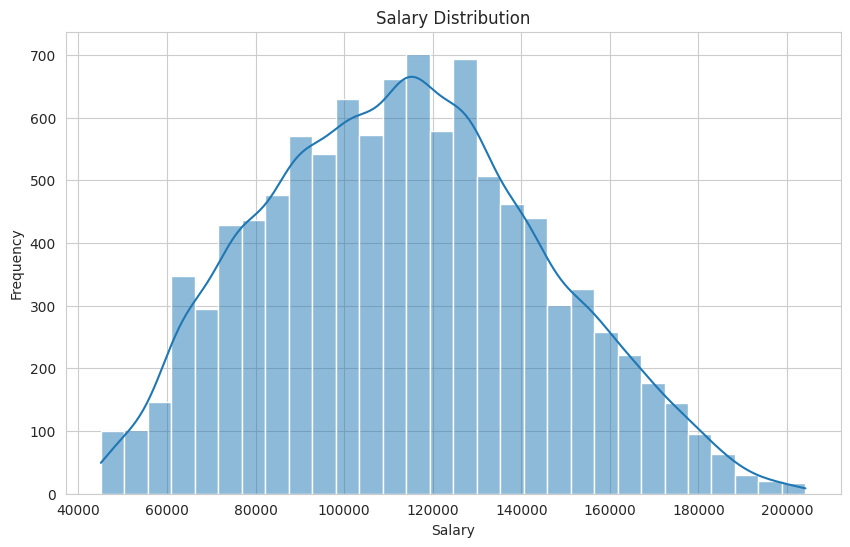

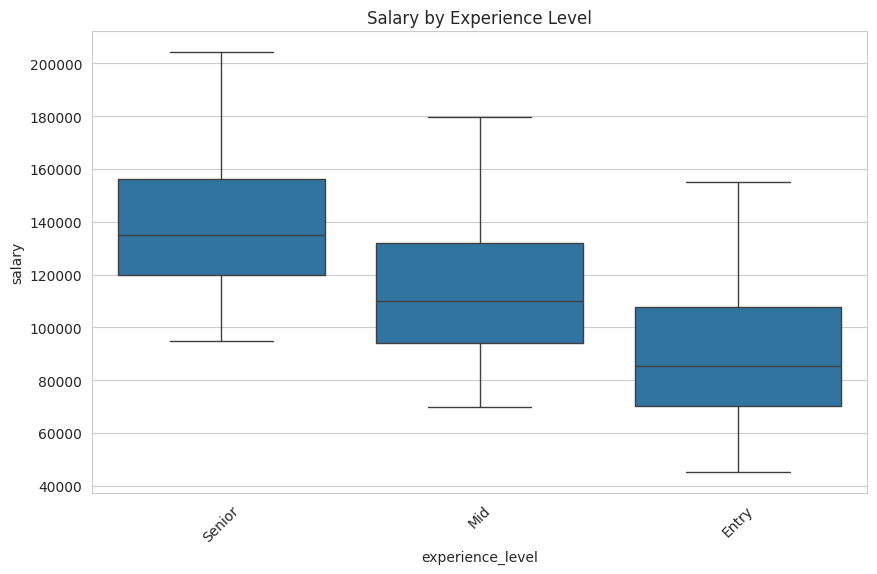

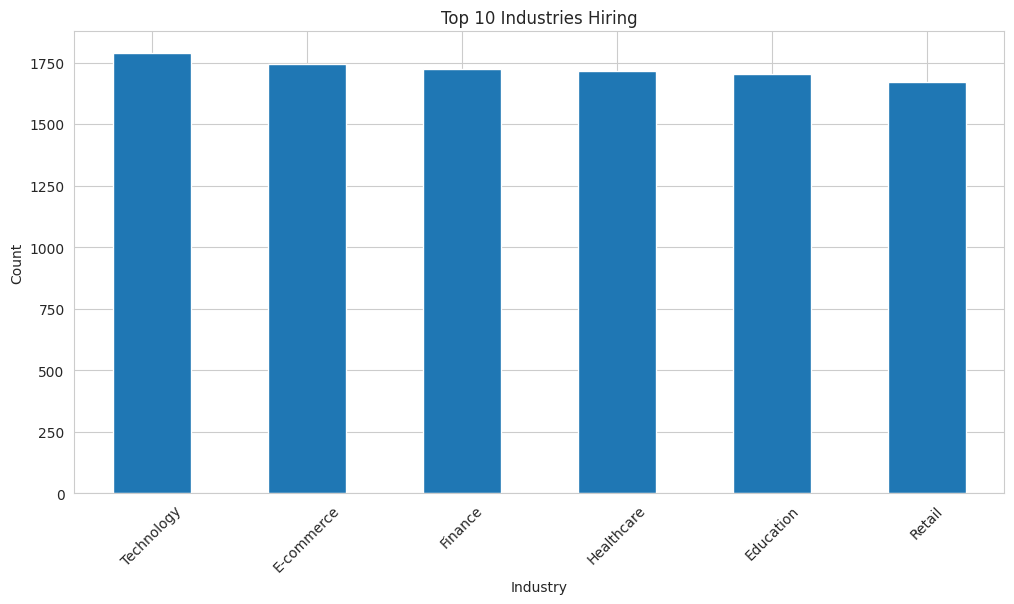

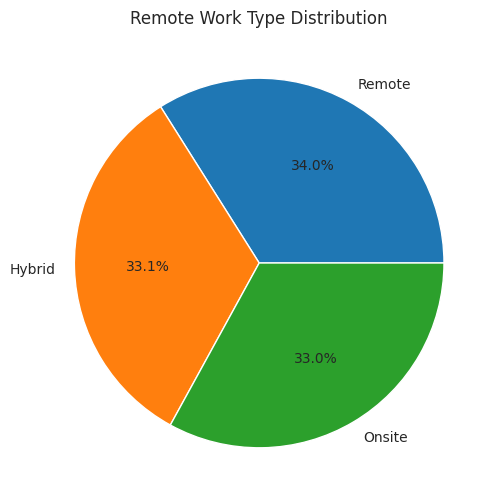

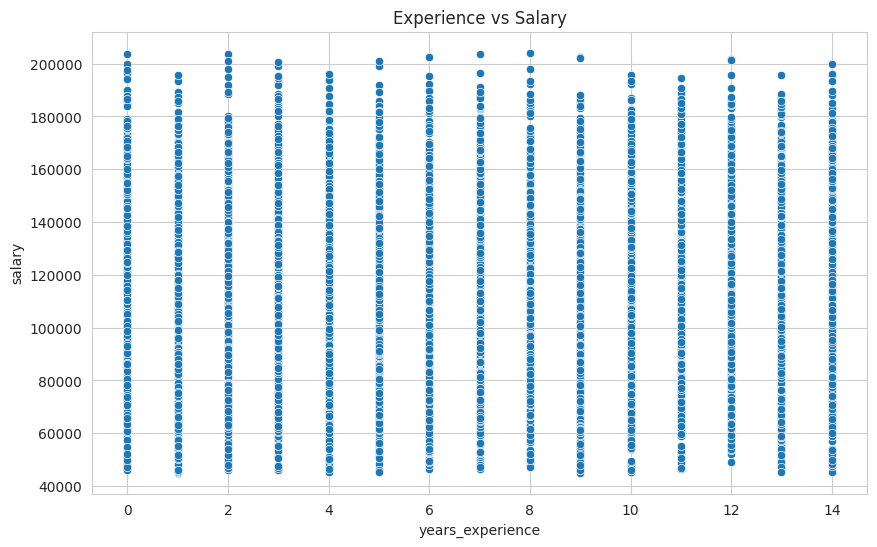

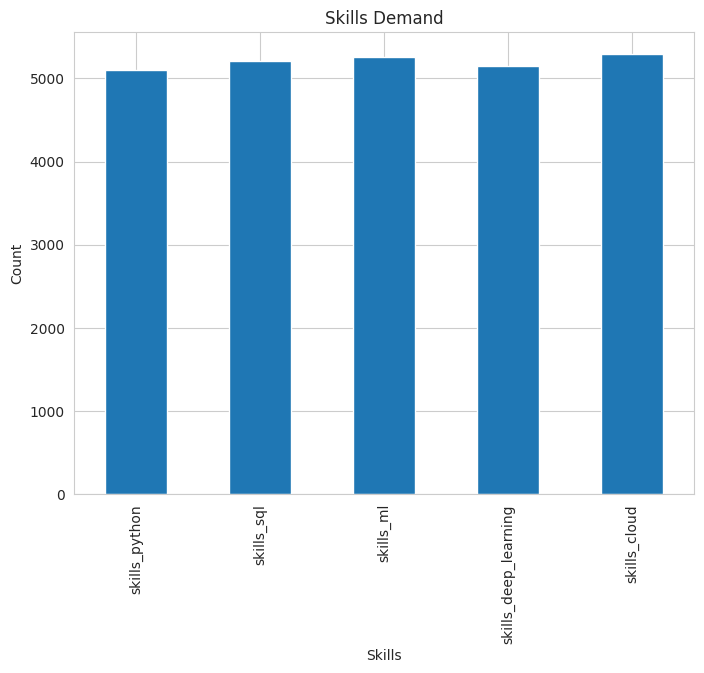

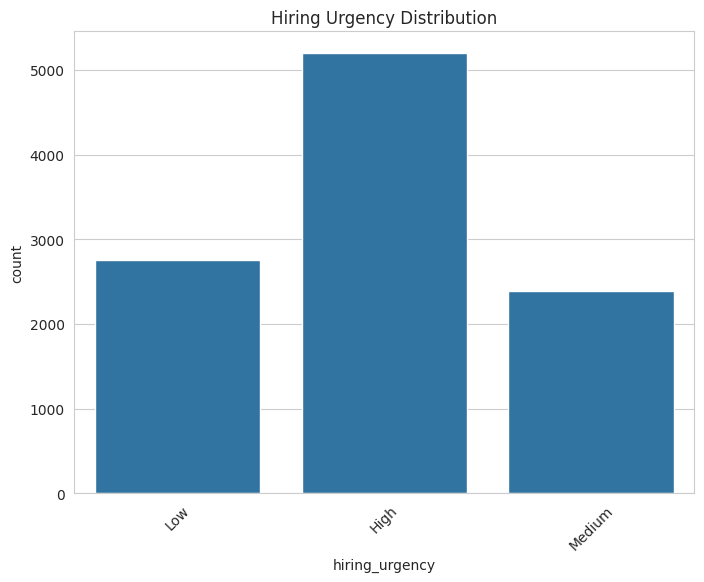

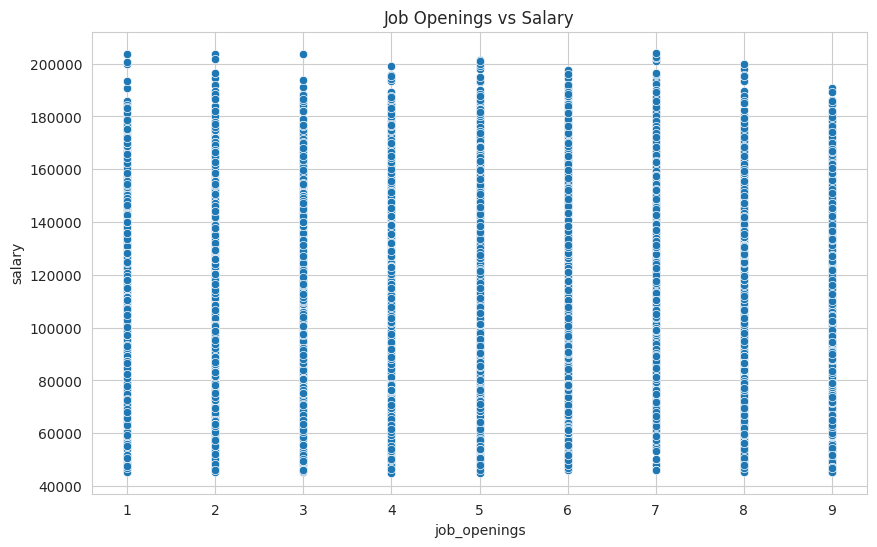

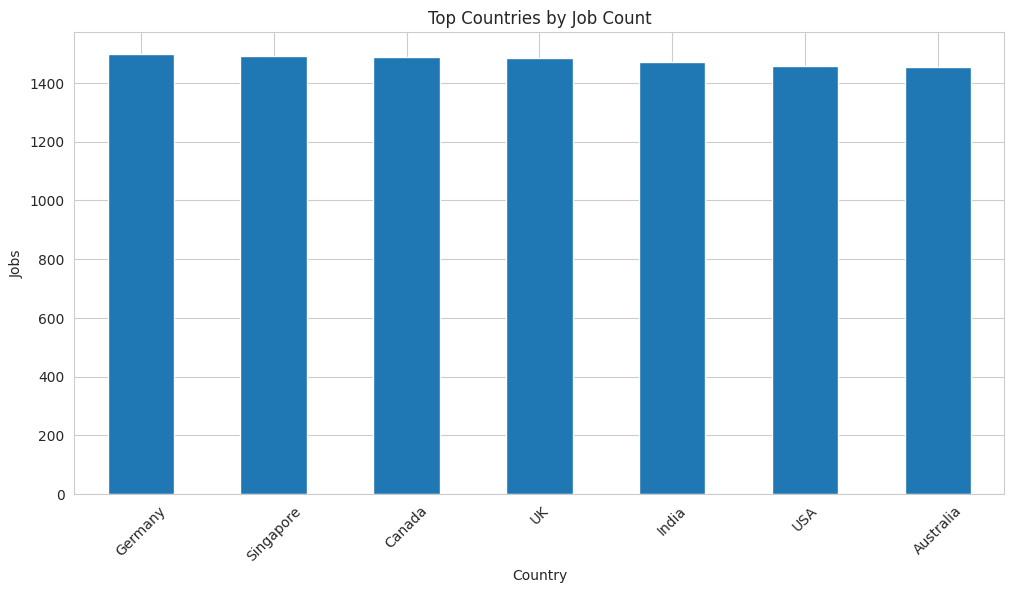

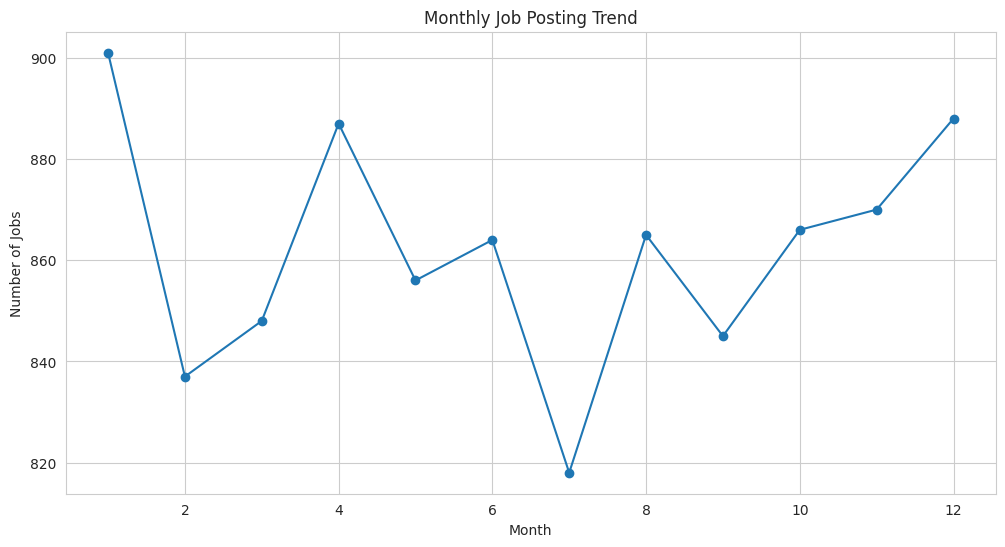

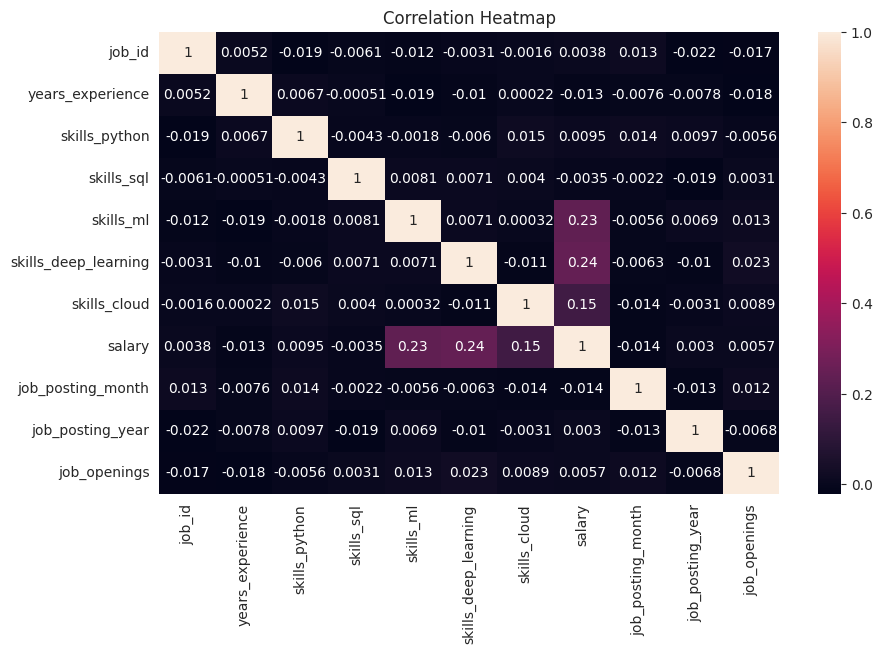

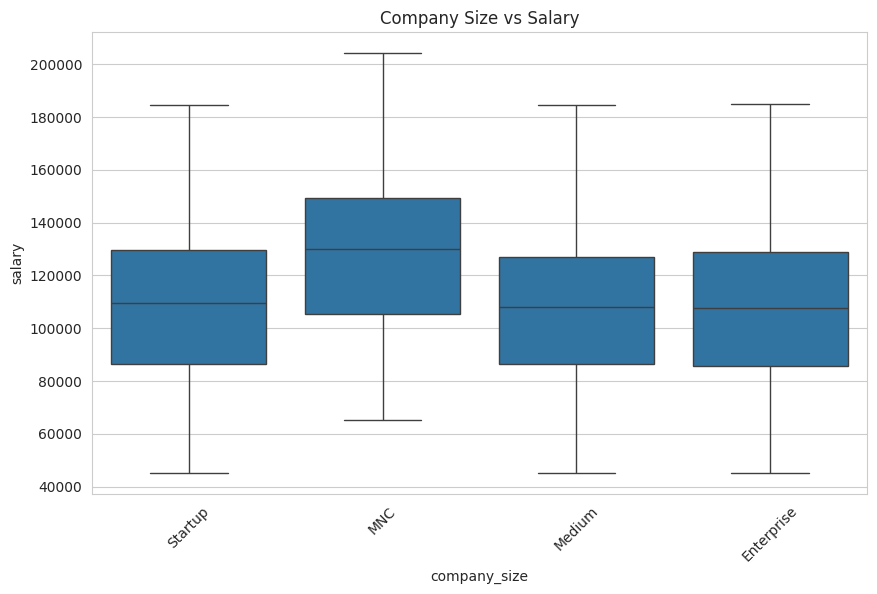

In [13]:
sns.set_style("whitegrid")

# =========================
# 1. Salary Distribution
# =========================
plt.figure(figsize=(10,6))
sns.histplot(df['salary'], kde=True, bins=30)
plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Frequency")
plt.show()

# =========================
# 2. Salary by Experience Level
# =========================
plt.figure(figsize=(10,6))
sns.boxplot(x='experience_level', y='salary', data=df)
plt.title("Salary by Experience Level")
plt.xticks(rotation=45)
plt.show()

# =========================
# 3. Jobs by Industry
# =========================
plt.figure(figsize=(12,6))
df['company_industry'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Industries Hiring")
plt.xlabel("Industry")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# =========================
# 4. Remote Work Distribution
# =========================
plt.figure(figsize=(6,6))
df['remote_type'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Remote Work Type Distribution")
plt.ylabel('')
plt.show()

# =========================
# 5. Experience vs Salary
# =========================
plt.figure(figsize=(10,6))
sns.scatterplot(x='years_experience', y='salary', data=df)
plt.title("Experience vs Salary")
plt.show()

# =========================
# 6. Skills Demand Analysis
# =========================
skills = ['skills_python', 'skills_sql', 'skills_ml', 
          'skills_deep_learning', 'skills_cloud']

skill_counts = df[skills].sum()

plt.figure(figsize=(8,6))
skill_counts.plot(kind='bar')
plt.title("Skills Demand")
plt.xlabel("Skills")
plt.ylabel("Count")
plt.show()

# =========================
# 7. Hiring Urgency Distribution
# =========================
plt.figure(figsize=(8,6))
sns.countplot(x='hiring_urgency', data=df)
plt.title("Hiring Urgency Distribution")
plt.xticks(rotation=45)
plt.show()

# =========================
# 8. Job Openings vs Salary
# =========================
plt.figure(figsize=(10,6))
sns.scatterplot(x='job_openings', y='salary', data=df)
plt.title("Job Openings vs Salary")
plt.show()

# =========================
# 9. Country-wise Jobs
# =========================
plt.figure(figsize=(12,6))
df['country'].value_counts().head(10).plot(kind='bar')
plt.title("Top Countries by Job Count")
plt.xlabel("Country")
plt.ylabel("Jobs")
plt.xticks(rotation=45)
plt.show()

# =========================
# 10. Monthly Job Posting Trend
# =========================
plt.figure(figsize=(12,6))
monthly_jobs = df.groupby('job_posting_month')['job_id'].count()
monthly_jobs.plot(kind='line', marker='o')
plt.title("Monthly Job Posting Trend")
plt.xlabel("Month")
plt.ylabel("Number of Jobs")
plt.show()

# =========================
# 11. Heatmap (Correlation)
# =========================
plt.figure(figsize=(10,6))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

# =========================
# 12. Company Size vs Salary
# =========================
plt.figure(figsize=(10,6))
sns.boxplot(x='company_size', y='salary', data=df)
plt.title("Company Size vs Salary")
plt.xticks(rotation=45)
plt.show()

## Feature engineering


Logistic Regression
Accuracy: 0.833252779120348
ROC AUC: 0.9544518095044278

Classification Report:

              precision    recall  f1-score   support

        High       0.83      0.84      0.84      1039
         Low       0.83      0.83      0.83       551
      Medium       0.84      0.82      0.83       479

    accuracy                           0.83      2069
   macro avg       0.83      0.83      0.83      2069
weighted avg       0.83      0.83      0.83      2069


Decision Tree
Accuracy: 1.0
ROC AUC: 1.0

Classification Report:

              precision    recall  f1-score   support

        High       1.00      1.00      1.00      1039
         Low       1.00      1.00      1.00       551
      Medium       1.00      1.00      1.00       479

    accuracy                           1.00      2069
   macro avg       1.00      1.00      1.00      2069
weighted avg       1.00      1.00      1.00      2069


Random Forest
Accuracy: 1.0
ROC AUC: 1.0

Classification Report:

  

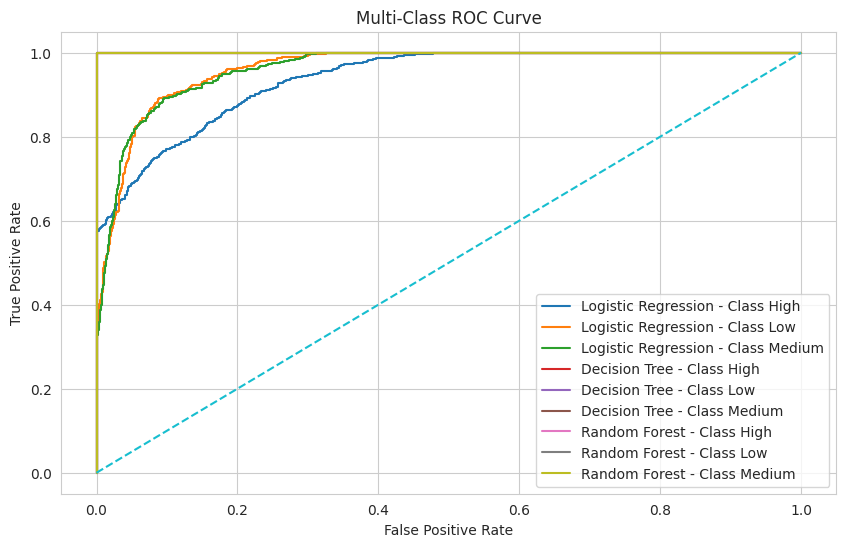


MODEL COMPARISON
                     Accuracy   ROC AUC
Logistic Regression  0.833253  0.954452
Decision Tree        1.000000  1.000000
Random Forest        1.000000  1.000000


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_auc_score,
    roc_curve
)


# =========================
# Target & Features
# =========================
target = 'hiring_urgency'

X = df.drop(columns=[target, 'job_id'])  # drop ID
y = df[target]

# =========================
# Column Types
# =========================
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# =========================
# Train-Test Split (NO LEAKAGE)
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================
# Preprocessing
# =========================
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

# =========================
# Models
# =========================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42)
}

# =========================
# Prepare ROC (Multi-class)
# =========================
classes = np.unique(y_train)
y_test_bin = label_binarize(y_test, classes=classes)

results = {}

# =========================
# Training + Evaluation
# =========================
for name, model in models.items():
    
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    # Train
    pipeline.fit(X_train, y_train)
    
    # Predict
    y_pred = pipeline.predict(X_test)
    
    # Probabilities
    if hasattr(model, "predict_proba"):
        y_prob = pipeline.predict_proba(X_test)
    else:
        y_prob = pipeline.decision_function(X_test)
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    
    roc_auc = roc_auc_score(
        y_test_bin,
        y_prob,
        multi_class='ovr'
    )
    
    results[name] = (acc, roc_auc)
    
    print("\n==============================")
    print(name)
    print("==============================")
    print("Accuracy:", acc)
    print("ROC AUC:", roc_auc)
    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))

# =========================
# ROC Curve Plot (Multi-class)
# =========================
plt.figure(figsize=(10,6))

for name, model in models.items():
    
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    pipeline.fit(X_train, y_train)
    
    if hasattr(model, "predict_proba"):
        y_prob = pipeline.predict_proba(X_test)
    else:
        y_prob = pipeline.decision_function(X_test)
    
    for i in range(len(classes)):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
        plt.plot(fpr, tpr, label=f"{name} - Class {classes[i]}")

# Diagonal line
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-Class ROC Curve")
plt.legend()
plt.show()

# =========================
# Final Results Table
# =========================
results_df = pd.DataFrame(results, index=["Accuracy", "ROC AUC"]).T

print("\n==============================")
print("MODEL COMPARISON")
print("==============================")
print(results_df)

## Thank you..pls upvote!!!!!!!